# Phân khúc khách hàng — K-Medoids (PAM) from Scratch

### **Bài toán:** 
**Customer Personality Analysis** là bài toán khai phá cấu trúc tiềm ẩn từ hồ sơ khách hàng của doanh nghiệp. Dữ liệu gồm hai nhóm thông tin chính:

- Nhân khẩu học: tuổi, thu nhập, trình độ học vấn, tình trạng hôn nhân, số con trong gia đình, thời gian gắn bó với công ty.
- Hành vi mua sắm & marketing: chi tiêu theo từng nhóm sản phẩm, kênh mua (web, catalogue, cửa hàng), tần suất truy cập web, phản hồi các chiến dịch khuyến mãi.

**Mục tiêu Notebook:** gom nhóm khách hàng có đặc điểm tương đồng để doanh nghiệp tối ưu chăm sóc, cá nhân hóa marketing bằng thuật toán **K-Medoids (PAM)**.

**Pipeline:**
1. Khám phá dữ liệu (PCA 2D)
2. Cài đặt PAM + Silhouette from scratch
3. Quét K (Elbow + Silhouette) → chọn K=4
4. Profile cụm, medoid, CSV, biểu đồ

**Input:** `customer_personality_preprocessed.csv`

**Output:** `customer_personality_clustered_v2.csv`, `labels`, `medoid_indices_`, `medoids`, `total_cost_`


### **[GIAI ĐOẠN 1]: TÌM HIỂU VÀ CHUẨN BỊ DỮ LIỆU**

In [1]:
# ==============================================================================
# IMPORT
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline
sns.set_theme(style="whitegrid")


In [2]:
# ==============================================================================
# ĐỌC DỮ LIỆU 
# ==============================================================================
try:
    df = pd.read_csv('customer_personality_preprocessed.csv')
    print("Nạp dữ liệu thành công! Kích thước tập dữ liệu:", df.shape)

    # Chỉ lấy cột đặc trưng (loại Cluster nếu chạy lại notebook)
    FEATURE_COLS = [c for c in df.columns if c != 'Cluster']
    X = df[FEATURE_COLS].values
    print(f"Ma trận đặc trưng: {X.shape} ({len(FEATURE_COLS)} cột)")
except FileNotFoundError:
    print("Không tìm thấy file 'customer_personality_preprocessed.csv'. Hãy kiểm tra lại đường dẫn.")

Nạp dữ liệu thành công! Kích thước tập dữ liệu: (2237, 24)
Ma trận đặc trưng: (2237, 24) (24 cột)


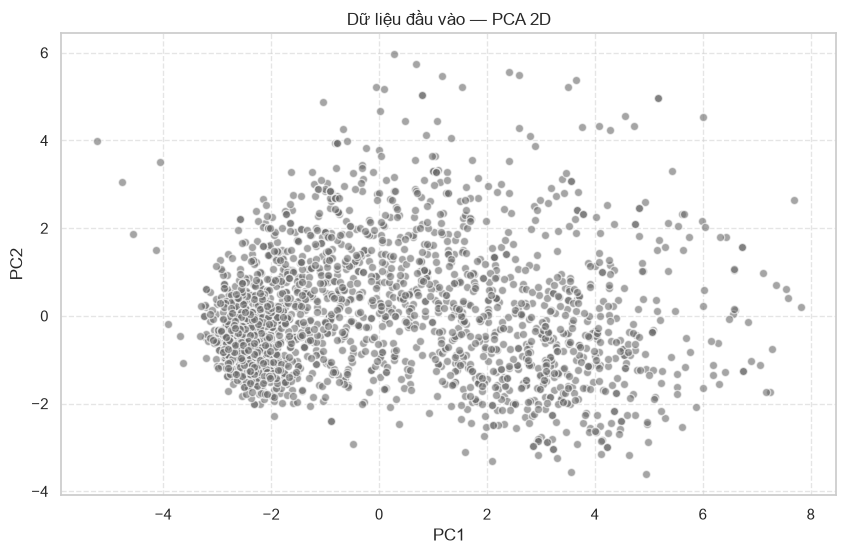

In [3]:
# ==============================================================================
# PCA FROM SCRATCH (chỉ visualize)
# ==============================================================================

def pca_project(X, n_components=2):
    mean = np.mean(X, axis=0)
    X_centered = X - mean
    cov_matrix = np.cov(X_centered, rowvar=False)
    eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)
    sorted_index = np.argsort(eigen_values)[::-1]
    components = eigen_vectors[:, sorted_index[:n_components]]
    return (X_centered @ components), components, mean


def pca_transform(X, components, mean):
    return (X - mean) @ components


X_pca, pca_components, X_mean = pca_project(X, n_components=2)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, color='dimgray', edgecolors='w', s=35)
plt.title('Dữ liệu đầu vào — PCA 2D')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### **[GIAI ĐOẠN 2]: K-MEDOIDS (PAM) FROM SCRATCH**


In [4]:
# ==============================================================================
# Định nghĩa lớp K-MEDOIDS FROM SCRATCH
# ==============================================================================

class KMedoidsFromScratch:
    def __init__(self, n_clusters=3, max_iters=100, random_state=42, verbose=False):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.verbose = verbose
        self.medoids = None
        self.medoid_indices_ = None
        self.labels = None
        self.total_cost_ = None
        self.n_iters_ = None

    def _init_medoids_plusplus(self, X, D=None):
        """Khởi tạo medoids theo K-Medoids++ (lưu index, tránh trùng)."""
        rng = np.random.default_rng(self.random_state)
        n_samples = X.shape[0]
        chosen = [int(rng.integers(0, n_samples))]

        for _ in range(1, self.n_clusters):
            if D is not None:
                dists = np.min(D[:, chosen], axis=1)
            else:
                medoids = X[chosen]
                dists = np.min(
                    np.linalg.norm(X[:, np.newaxis] - medoids, axis=2),
                    axis=1,
                )

            remaining = np.setdiff1d(np.arange(n_samples), chosen)
            if len(remaining) == 0:
                break

            weights = dists[remaining]
            if weights.sum() == 0:
                probs = np.full(len(remaining), 1.0 / len(remaining))
            else:
                probs = weights / weights.sum()
            chosen.append(int(rng.choice(remaining, p=probs)))

        return np.array(chosen, dtype=int)

    def _assign_clusters_with_medoid_indices(self, X, medoid_indices, D=None):
        """Gán cụm theo bộ index medoid cho trước."""
        if D is not None:
            distances = D[:, medoid_indices]
        else:
            medoids = X[medoid_indices]
            distances = np.linalg.norm(X[:, np.newaxis] - medoids, axis=2)
        return np.argmin(distances, axis=1)

    def _compute_cost(self, X, medoid_indices, D=None):
        """Total Cost (TDAD) = tổng khoảng cách từ mỗi điểm đến medoid gần nhất."""
        if D is not None:
            return float(np.min(D[:, medoid_indices], axis=1).sum())
        medoids = X[medoid_indices]
        distances = np.linalg.norm(X[:, np.newaxis] - medoids, axis=2)
        return float(np.min(distances, axis=1).sum())

    def _find_best_swap(self, X, medoid_indices, medoid_set, current_cost, D=None):
        """Tìm cặp (medoid_i, điểm_j) giảm cost nhiều nhất."""
        n_samples = X.shape[0]
        best_cost = current_cost
        best_indices = None

        for i in range(self.n_clusters):
            for j in range(n_samples):
                if j in medoid_set:
                    continue

                new_indices = medoid_indices.copy()
                new_indices[i] = j
                new_cost = self._compute_cost(X, new_indices, D=D)

                if new_cost < best_cost:
                    best_cost = new_cost
                    best_indices = new_indices

        return best_indices, best_cost

    def fit(self, X, D=None):
        """PAM: mỗi iteration = 1 pass (gán cụm → swap tốt nhất → áp dụng)."""
        X = np.asarray(X)
        n_samples = X.shape[0]

        if not (1 <= self.n_clusters <= n_samples):
            raise ValueError(
                f"n_clusters={self.n_clusters} phải nằm trong [1, {n_samples}]"
            )

        if D is not None:
            D = np.asarray(D)
            if D.shape != (n_samples, n_samples):
                raise ValueError(
                    f"D phải có shape ({n_samples}, {n_samples}), nhận {D.shape}"
                )

        self.medoid_indices_ = self._init_medoids_plusplus(X, D=D)
        self.medoids = X[self.medoid_indices_].copy()
        medoid_set = set(self.medoid_indices_.tolist())
        self.n_iters_ = 0

        while self.n_iters_ < self.max_iters:
            self.labels = self._assign_clusters_with_medoid_indices(
                X, self.medoid_indices_, D=D
            )
            current_cost = self._compute_cost(X, self.medoid_indices_, D=D)

            best_indices, _ = self._find_best_swap(
                X, self.medoid_indices_, medoid_set, current_cost, D=D
            )

            if best_indices is None:
                if self.verbose:
                    print(f"Hội tụ sau {self.n_iters_} pass PAM.")
                break

            self.medoid_indices_ = best_indices
            self.medoids = X[self.medoid_indices_].copy()
            medoid_set = set(self.medoid_indices_.tolist())
            self.n_iters_ += 1
        else:
            if self.verbose:
                print(
                    f"Đạt max_iters={self.max_iters} "
                    f"(đã thực hiện {self.n_iters_} pass PAM)."
                )

        self.labels = self._assign_clusters_with_medoid_indices(
            X, self.medoid_indices_, D=D
        )
        self.total_cost_ = self._compute_cost(X, self.medoid_indices_, D=D)
        return self

    def predict(self, X):
        """Dự đoán nhãn (dữ liệu mới phải cùng pipeline chuẩn hóa)."""
        if self.medoids is None:
            raise ValueError("Mô hình chưa được huấn luyện. Hãy chạy .fit() trước.")
        X = np.asarray(X)
        distances = np.linalg.norm(X[:, np.newaxis] - self.medoids, axis=2)
        return np.argmin(distances, axis=1)

# ==============================================================================
# Ma trận khoảng cách & Silhouette Score FROM SCRATCH
# ==============================================================================

def compute_pairwise_distance_matrix(X):
    """Tiền tính ma trận khoảng cách Euclidean đầy đủ (n x n)."""
    return np.linalg.norm(X[:, np.newaxis] - X[np.newaxis, :], axis=2)


def silhouette_score_from_scratch(X, labels, D=None):
    """Silhouette Score; truyền D đã tiền tính để tránh tính lại khoảng cách."""
    labels = np.asarray(labels)
    n_samples = labels.shape[0]
    unique_labels = np.unique(labels)

    if len(unique_labels) < 2:
        return 0.0

    if D is None:
        D = compute_pairwise_distance_matrix(X)

    a = np.zeros(n_samples)
    b = np.full(n_samples, np.inf)

    for label in unique_labels:
        mask = labels == label
        indices = np.where(mask)[0]
        cluster_size = len(indices)

        if cluster_size > 1:
            sub_D = D[np.ix_(indices, indices)]
            a[mask] = sub_D.sum(axis=1) / (cluster_size - 1)

        for other_label in unique_labels:
            if other_label == label:
                continue
            other_indices = np.where(labels == other_label)[0]
            mean_dists = D[np.ix_(indices, other_indices)].mean(axis=1)
            b[mask] = np.minimum(b[mask], mean_dists)

    s = (b - a) / np.maximum(a, b)
    return float(np.mean(s))


#### Nhận xét — Thuật toán K-Medoids (PAM)

- **Medoid** là một điểm dữ liệu thực trong tập — đại diện cụm dễ diễn giải nghiệp vụ.
- **PAM (best-swap):** gán cụm → tìm hoán đổi medoid giảm **Total Cost** nhiều nhất → lặp đến hội tụ. `fit(X, D=D)` tái dùng ma trận khoảng cách.
- **K-Medoids++** chọn medoid ban đầu cách xa nhau, giảm hội tụ cục bộ.
- **Silhouette Score** đo độ tách cụm (càng gần 1 càng tốt).


### **[GIAI ĐOẠN 3]: CHỌN K & HUẤN LUYỆN**
- Quét K = 2…10, lưu `models_k`.
- Elbow (Total Cost) + Silhouette.


In [13]:
# ==============================================================================
# QUÉT K & ĐÁNH GIÁ (TOTAL COST + SILHOUETTE)
# ==============================================================================

D = compute_pairwise_distance_matrix(X)

models_k = {}
total_cost_list = []
silhouette_list = []
n_iters_list = []
k_range = range(2, 11)

print("Quét K cho K-Medoids (PAM)...")
print(f"Ma trận khoảng cách: {D.shape}\n")

for k in k_range:
    model = KMedoidsFromScratch(
        n_clusters=k, max_iters=100, random_state=42, verbose=False
    )
    model.fit(X, D=D)
    models_k[k] = model

    total_cost_list.append(model.total_cost_)
    score = silhouette_score_from_scratch(X, model.labels, D=D)
    silhouette_list.append(score)
    n_iters_list.append(model.n_iters_)

    print(
        f"K={k} | Total Cost={model.total_cost_:.2f} | "
        f"Silhouette={score:.4f} | Hội tụ sau {model.n_iters_} iterations"
    )



Quét K cho K-Medoids (PAM)...
Ma trận khoảng cách: (2237, 2237)

K=2 | Total Cost=9560.04 | Silhouette=0.2274 | Hội tụ sau 3 iterations
K=3 | Total Cost=9276.73 | Silhouette=0.0700 | Hội tụ sau 5 iterations
K=4 | Total Cost=9003.53 | Silhouette=0.0692 | Hội tụ sau 6 iterations
K=5 | Total Cost=8762.02 | Silhouette=0.0552 | Hội tụ sau 8 iterations
K=6 | Total Cost=8525.61 | Silhouette=0.0673 | Hội tụ sau 12 iterations
K=7 | Total Cost=8394.72 | Silhouette=0.0643 | Hội tụ sau 10 iterations
K=8 | Total Cost=8212.92 | Silhouette=0.0652 | Hội tụ sau 11 iterations
K=9 | Total Cost=8073.58 | Silhouette=0.0714 | Hội tụ sau 10 iterations
K=10 | Total Cost=7939.30 | Silhouette=0.0748 | Hội tụ sau 12 iterations


#### Nhận xét — Chọn K

| K | Total Cost ↓ | Silhouette ↑ |
|---:|---:|---:|
| 2 | 9.560 | **0,227** |
| 3 | 9.277 | 0,070 |
| 4 | **9.004** | 0,069 |
| 5 | 8.762 | 0,055 |

- **Elbow:** cost giảm mạnh đến K=4, sau đó chậm lại → chọn **K = 4**.
- **Silhouette** cao nhất ở K=2 (0,227) nhưng quá thô; K=4 (0,069) gần K=3 và cân bằng chi tiết nghiệp vụ.


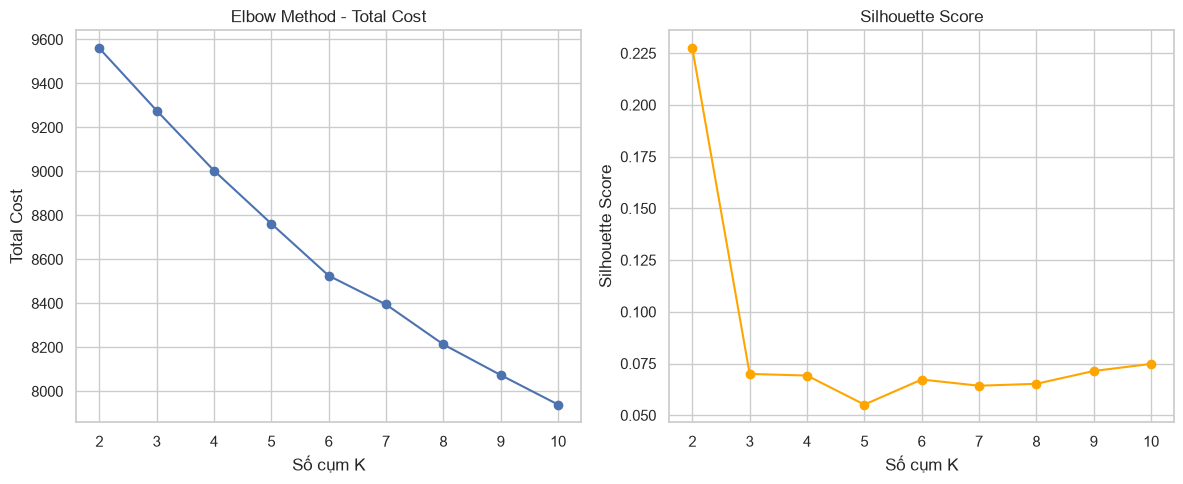

In [6]:
# ==============================================================================
# TRỰC QUAN HÓA TOTAL COST & SILHOUETTE
# ==============================================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, total_cost_list, marker='o')
plt.title('Elbow Method - Total Cost')
plt.xlabel('Số cụm K')
plt.ylabel('Total Cost')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_list, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Số cụm K')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

### **[GIAI ĐOẠN 4]: KẾT QUẢ PHÂN KHÚC**
- Lấy mô hình K=4 từ `models_k` (không train lại).
- Profile cụm, medoid đại diện, xuất CSV, scatter PCA 2D.


In [7]:
# ==============================================================================
# CHỌN MÔ HÌNH K TỐI ƯU (tái sử dụng từ vòng quét K, không train lại)
# ==============================================================================

optimal_k = 4   # Thay đổi dựa trên kết quả Elbow / Silhouette ở trên

final_model = models_k[optimal_k]
df['Cluster'] = final_model.labels

print("=== SỐ LƯỢNG KHÁCH HÀNG TRONG MỖI PHÂN KHÚC ===")
print(df['Cluster'].value_counts().sort_index())

print("\n=== MEDOID ĐẠI DIỆN TỪNG CỤM (index hàng trong df) ===")
for cluster_id, medoid_idx in enumerate(final_model.medoid_indices_):
    print(f"  Cụm {cluster_id}: medoid_indices_ = {medoid_idx}")

=== SỐ LƯỢNG KHÁCH HÀNG TRONG MỖI PHÂN KHÚC ===
Cluster
0    492
1    328
2    830
3    587
Name: count, dtype: int64

=== MEDOID ĐẠI DIỆN TỪNG CỤM (index hàng trong df) ===
  Cụm 0: medoid_indices_ = 898
  Cụm 1: medoid_indices_ = 795
  Cụm 2: medoid_indices_ = 82
  Cụm 3: medoid_indices_ = 2235


#### Nhận xét — Phân bố cụm và Medoids (K = 4)

| Cụm | Số KH | Tỷ lệ | Medoid (index) |
|---|---:|---:|---:|
| 0 | 492 | 22,0% | 898 |
| 1 | 328 | 14,7% | 795 |
| 2 | 830 | 37,1% | 82 |
| 3 | 587 | 26,2% | 2235 |

- Phân bố **lệch**: Cụm 2 chiếm 37,1% (lớn nhất), Cụm 1 nhỏ nhất 14,7% — cần lưu ý khi thiết kế chiến dịch theo tỷ trọng cụm.
- **Medoid** là khách hàng thực tế đại diện cho cụm — có thể tra cứu trực tiếp trong `df` để xem hồ sơ cụ thể, hữu ích cho đội CRM khi xây dựng persona.
- Total Cost tại K=4: **9.003,53** (so với 9.560 tại K=2, giảm ~5,8%).


In [8]:
# ==============================================================================
# PROFILE CỤM (TRUNG BÌNH CHUẨN HÓA THEO CLUSTER)
# ==============================================================================

cluster_summary = df.groupby('Cluster').mean().round(2)
cluster_summary


,Education,Marital_Status,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,DaysCustomer,Age,children
Cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.18,-1.23,-0.35,-0.45,-0.45,-0.50,-0.48,-0.44,-0.31,0.06,...,0.02,-0.04,-0.25,-0.20,-0.03,-0.01,-0.07,-0.08,-0.04,0.34
1,-0.30,-0.07,0.95,0.89,1.53,1.57,1.49,1.52,0.63,-0.48,...,0.01,0.04,0.65,0.62,0.07,-0.03,0.41,0.34,-0.32,-1.01
2,-0.00,0.65,-0.65,-0.66,-0.51,-0.59,-0.51,-0.51,-0.43,0.13,...,-0.02,-0.18,-0.27,-0.24,-0.10,0.02,-0.16,-0.01,-0.21,0.41
3,0.33,0.15,0.68,0.82,0.25,0.38,0.29,0.25,0.52,0.04,...,0.00,0.27,0.23,0.17,0.12,-0.00,0.05,-0.11,0.51,-0.30


#### Nhận xét — Chân dung 4 phân khúc khách hàng

*(Giá trị trong bảng là trung bình đã chuẩn hóa; dương = cao hơn trung bình toàn tập, âm = thấp hơn)*

**Cụm 1 — Khách hàng giá trị cao (VIP)** · 328 KH
- Thu nhập cao (+0,95), chi tiêu vượt trội mọi nhóm sản phẩm (thịt +1,57, trái cây +1,53, rượu +0,89).
- Ít con (-1,01), ít duyệt web (-0,94), mua chủ yếu qua catalogue (+1,11) & cửa hàng (+0,87).
- Phản hồi chiến dịch tích cực (AcceptedCmp5 +0,65, AcceptedCmp1 +0,62, Response +0,41).
- *Chiến lược:* chương trình loyalty cao cấp, ưu đãi cá nhân hóa sản phẩm premium (rượu, thịt).

**Cụm 2 — Gia đình chi tiêu thấp** · 830 KH
- Cụm lớn nhất: thu nhập thấp (-0,65), chi tiêu thấp toàn danh mục, nhiều con (+0,41), tình trạng hôn nhân cao (+0,65).
- Duyệt web nhiều (+0,57) nhưng mua ít (web -0,47, cửa hàng -0,66) — quan tâm nhưng chưa chuyển đổi.
- *Chiến lược:* gói combo gia đình giá mềm, khuyến mãi theo mùa, nuôi dưỡng từ awareness → purchase.

**Cụm 0 — Khách thụ động / ít tương tác** · 492 KH
- Thu nhập và chi tiêu đều thấp, tình trạng hôn nhân khác biệt (-1,23), nhiều con (+0,34).
- Duyệt web (+0,34) nhưng mua catalogue/cửa hàng thấp; phản hồi chiến dịch âm (AcceptedCmp5 -0,25).
- *Chiến lược:* khảo sát nhu cầu, ưu đãi kích hoạt lần mua đầu, remarketing nhẹ nhàng.

**Cụm 3 — Khách trung-cao tuổi / kênh truyền thống** · 587 KH
- Thu nhập khá (+0,68), tuổi cao hơn (+0,51), học vấn cao (+0,33), chi tiêu trung bình-khá (rượu +0,82).
- Mua web (+0,64), catalogue (+0,73) và cửa hàng (+0,84) đều cao; ít duyệt web (-0,57).
- *Chiến lược:* catalogue marketing, ưu đãi in-store, kênh truyền thống & đa kênh.


In [9]:
# ==============================================================================
# XUẤT CSV KẾT QUẢ
# ==============================================================================

output_path = 'customer_personality_clustered_v2.csv'
df.to_csv(output_path, index=False)
print(f"Đã lưu: {output_path} ({df.shape[0]} × {df.shape[1]})")
print(df['Cluster'].value_counts().sort_index())


Đã lưu: customer_personality_clustered_v2.csv (2237 × 25)
Cluster
0    492
1    328
2    830
3    587
Name: count, dtype: int64


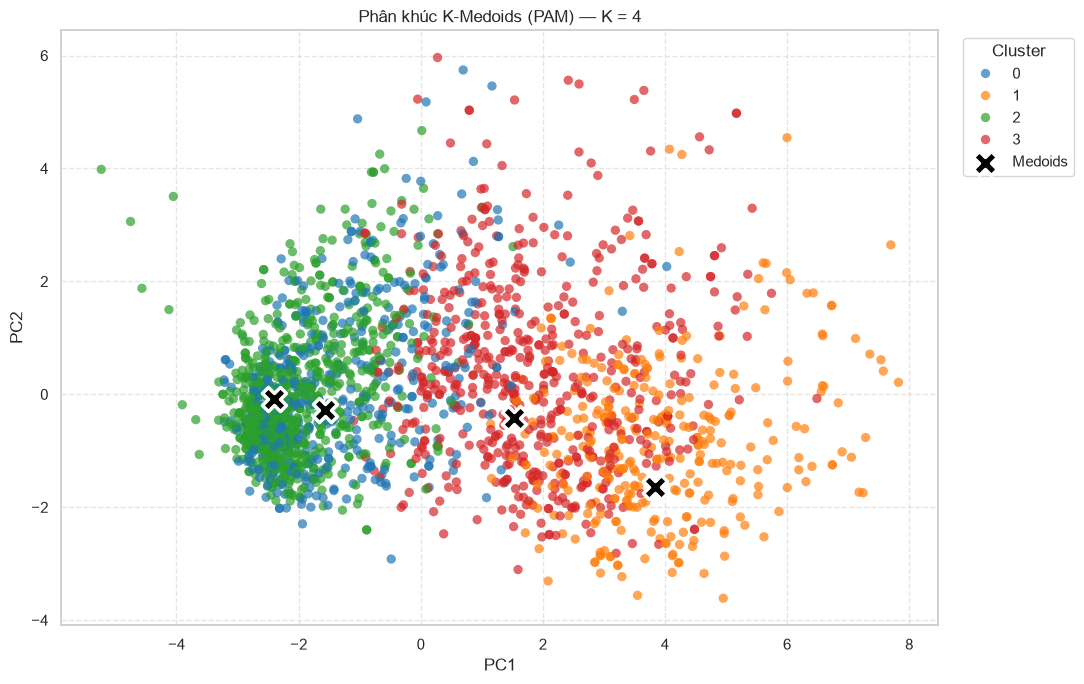

In [10]:
# ==============================================================================
# SCATTER PCA 2D — PHÂN KHÚC & MEDOIDS
# ==============================================================================

medoids_pca = pca_transform(final_model.medoids, pca_components, X_mean)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=df['Cluster'], palette='tab10',
    alpha=0.7, s=45, edgecolor='none',
)
plt.scatter(
    medoids_pca[:, 0], medoids_pca[:, 1],
    color='black', marker='X', s=300,
    label='Medoids', edgecolor='white', linewidth=2.5,
)
plt.title(f'Phân khúc K-Medoids (PAM) — K = {final_model.n_clusters}')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#### Nhận xét — Scatter PCA 2D

- PCA 2D chỉ để visualize; clustering chạy trên 24 đặc trưng gốc.
- Medoid (X đen) nằm gần trung tâm mật độ từng cụm — đúng vai trò đại diện PAM.
